# Model Comparison Notebook

This notebook reads the saved results from every standalone model notebook and produces fair side-by-side comparison plots and summary tables.


## Run Safety

Before running this notebook, restart the kernel.

Why this matters:
- previous model runs can leave tensors and cached arrays in memory
- old variables can leak into the current run and make comparisons unfair
- we want every notebook to save a clean, reproducible result

Recommended workflow:
1. Restart kernel
2. Run all cells from top to bottom
3. Let the notebook save its outputs before closing it


In [1]:
# Memory cleanup before starting this notebook.
import gc

gc.collect()
try:
    import torch
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
except Exception:
    pass

print('Kernel memory cleanup complete. Start the notebook from here after a restart.')


Kernel memory cleanup complete. Start the notebook from here after a restart.


In [2]:
# Standard-library imports used throughout the evaluation notebooks.
import json
import math
import random
from collections import Counter
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path
from datetime import datetime
from IPython.display import display

# Core scientific / ML stack.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset

# ROC / PR curves are useful for classification comparison if sklearn is available.
try:
    from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
    from sklearn.preprocessing import label_binarize
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

# Resolve the project root robustly no matter where Jupyter was launched from.
SEARCH_ROOT = Path.cwd().resolve()
PROJECT_ROOT = SEARCH_ROOT
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'Thesis_Repo').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

THESIS_ROOT = PROJECT_ROOT / 'Thesis_Repo'
NOTEBOOK_ROOT = THESIS_ROOT / 'notebooks'
RESULTS_ROOT = THESIS_ROOT / 'results'
WEIGHTS_ROOT = THESIS_ROOT / 'model_weights'
SPLITS_ROOT = THESIS_ROOT / 'splits'
PLOTS_ROOT = THESIS_ROOT / 'plots'
DATASET_ROOT = PROJECT_ROOT / 'hybrid_maneuver_dataset'

print('Project root:', PROJECT_ROOT)
print('Thesis workspace:', THESIS_ROOT)
print('Dataset root:', DATASET_ROOT)
print('Torch version:', torch.__version__)
print('Sklearn available for ROC/PR plots:', SKLEARN_AVAILABLE)


Project root: /home/basudeo/Documents/Thesis
Thesis workspace: /home/basudeo/Documents/Thesis/Thesis_Repo
Dataset root: /home/basudeo/Documents/Thesis/hybrid_maneuver_dataset
Torch version: 2.3.1+cu118
Sklearn available for ROC/PR plots: True


In [3]:
MODEL_SLUGS = [
    'cv_baseline',
    'cnn_lstm',
    'gnn_lstm',
    'cnn_gnn_lstm',
    'cnn_gnn_transformer',
    'cnn_gnn_lstm_transformer',
]

summary_rows = []
latest_metrics = {}
for slug in MODEL_SLUGS:
    latest_metrics_path = RESULTS_ROOT / slug / 'latest_metrics.json'
    if latest_metrics_path.exists():
        with latest_metrics_path.open() as f:
            payload = json.load(f)
        latest_metrics[slug] = payload
        payload['model'] = slug
        summary_rows.append(payload)

summary_df = pd.DataFrame(summary_rows)
if summary_df.empty:
    raise RuntimeError('No latest_metrics.json files were found. Run the model notebooks first.')

display(summary_df)
print(summary_df.to_string())


,accuracy,macro_precision,macro_recall,macro_f1,confusion_matrix,ADE,FDE,RMSE,roc_auc_macro,pr_auc_macro,status,split_path,model,loss,best_val_macro_f1,trajectory_overlay_plots,mean_step_error_plot
0,0.416393,0.298564,0.541035,0.316313,"[[182, 23, 40, 16, 0], [0, 30, 0, 1, 0], [0, 1...",1.561741,2.601725,2.182193,0.686326,0.301701,saved,/home/basudeo/Documents/Thesis/Thesis_Repo/spl...,cv_baseline,NaN,NaN,NaN,NaN
1,0.672131,0.557255,0.573470,0.555491,"[[209, 8, 0, 15, 29], [7, 13, 4, 5, 2], [5, 8,...",0.308507,0.511918,0.419387,0.847514,0.572382,saved,/home/basudeo/Documents/Thesis/Thesis_Repo/spl...,cnn_lstm,1.026176,0.538796,[/home/basudeo/Documents/Thesis/Thesis_Repo/re...,/home/basudeo/Documents/Thesis/Thesis_Repo/res...
2,0.692708,0.299731,0.398276,0.341404,"[[115, 0, 1, 0, 0], [6, 0, 0, 0, 0], [7, 0, 0,...",NaN,NaN,NaN,0.773410,0.511248,saved,/home/basudeo/Documents/Thesis/Thesis_Repo/spl...,gnn_lstm,1.242015,0.362033,NaN,NaN
3,0.572131,0.453785,0.511130,0.470921,"[[141, 6, 6, 83, 25], [4, 3, 13, 9, 2], [1, 2,...",0.300089,0.490397,0.408637,0.800973,0.491799,saved,/home/basudeo/Documents/Thesis/Thesis_Repo/spl...,cnn_gnn_lstm,1.085715,0.503659,[/home/basudeo/Documents/Thesis/Thesis_Repo/re...,/home/basudeo/Documents/Thesis/Thesis_Repo/res...
4,0.622951,0.485220,0.552995,0.486923,"[[210, 2, 4, 16, 29], [7, 9, 7, 6, 2], [1, 2, ...",0.288399,0.476695,0.399177,0.842072,0.554559,saved,/home/basudeo/Documents/Thesis/Thesis_Repo/spl...,cnn_gnn_transformer,1.009478,0.475706,[/home/basudeo/Documents/Thesis/Thesis_Repo/re...,/home/basudeo/Documents/Thesis/Thesis_Repo/res...
5,0.657377,0.472371,0.548349,0.479148,"[[202, 0, 12, 16, 31], [7, 0, 16, 4, 4], [1, 0...",0.304640,0.506012,0.418296,0.841538,0.573718,saved,/home/basudeo/Documents/Thesis/Thesis_Repo/spl...,cnn_gnn_lstm_transformer,1.029276,0.544863,[/home/basudeo/Documents/Thesis/Thesis_Repo/re...,/home/basudeo/Documents/Thesis/Thesis_Repo/res...


   accuracy  macro_precision  macro_recall  macro_f1                                                                                    confusion_matrix       ADE       FDE      RMSE  roc_auc_macro  pr_auc_macro status                                                                                                 split_path                     model      loss  best_val_macro_f1                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [4]:
# Save a clean summary table for thesis reporting.
comparison_csv = THESIS_ROOT / 'comparison_exports' / 'model_summary_latest.csv'
comparison_json = THESIS_ROOT / 'comparison_exports' / 'model_summary_latest.json'
summary_df.to_csv(comparison_csv, index=False)
comparison_json.write_text(summary_df.to_json(orient='records', indent=2))
print('Saved comparison CSV:', comparison_csv)
print('Saved comparison JSON:', comparison_json)


Saved comparison CSV: /home/basudeo/Documents/Thesis/Thesis_Repo/comparison_exports/model_summary_latest.csv
Saved comparison JSON: /home/basudeo/Documents/Thesis/Thesis_Repo/comparison_exports/model_summary_latest.json


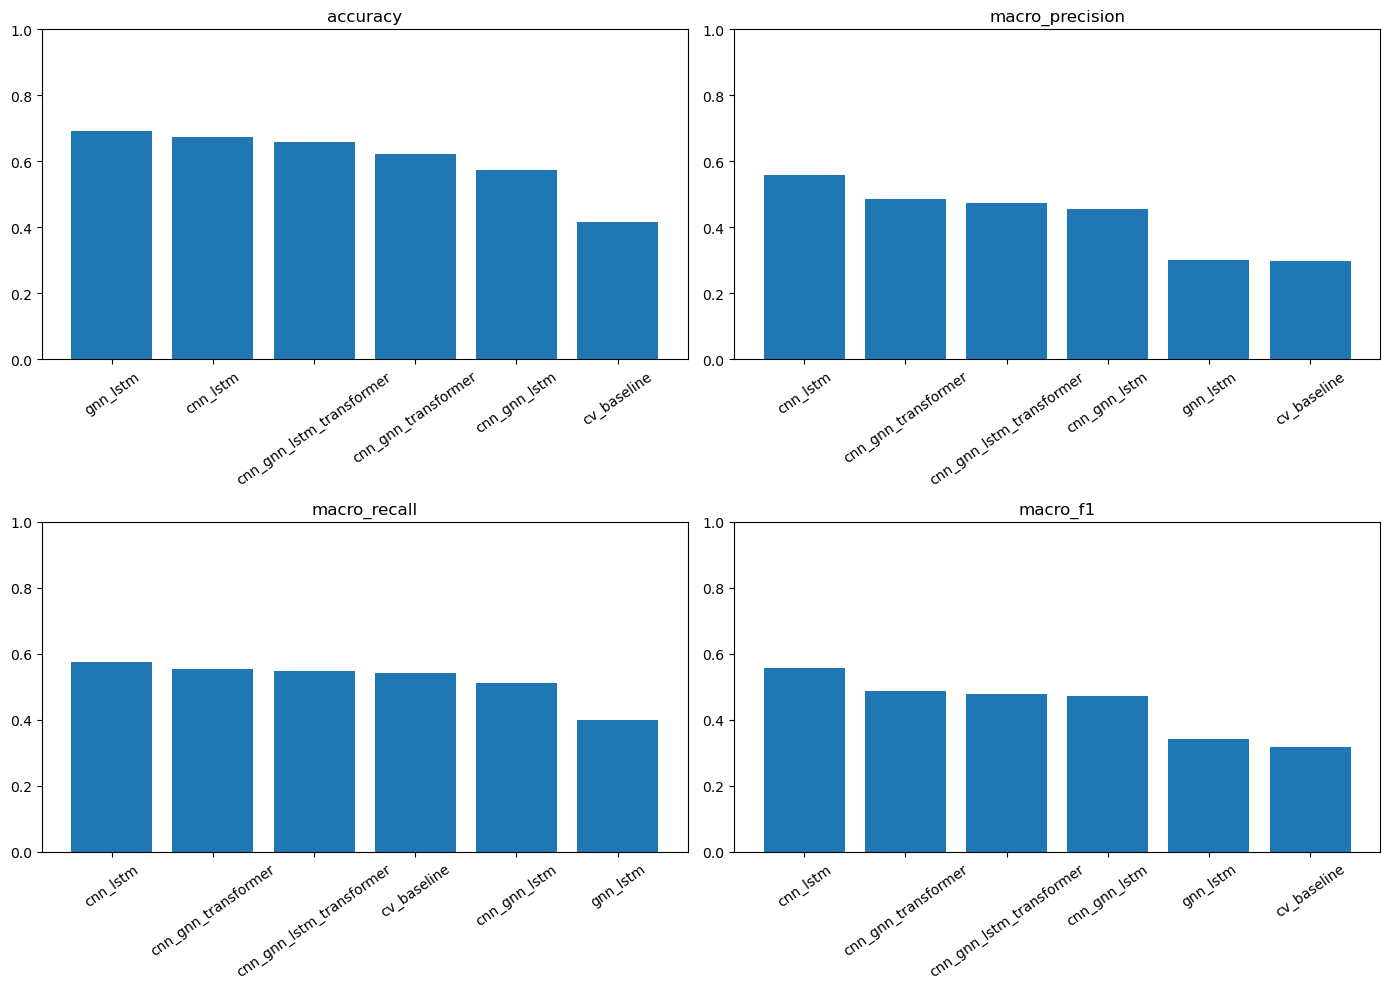

Saved: /home/basudeo/Documents/Thesis/Thesis_Repo/plots/comparison_metrics_bar.png


In [5]:
# Core classification metrics bar chart.
plot_metrics = ['accuracy', 'macro_precision', 'macro_recall', 'macro_f1']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, metric in zip(axes.flatten(), plot_metrics):
    ordered = summary_df.sort_values(metric, ascending=False)
    ax.bar(ordered['model'], ordered[metric])
    ax.set_title(metric)
    ax.set_ylim(0.0, 1.0)
    ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
out_path = THESIS_ROOT / 'plots' / 'comparison_metrics_bar.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', out_path)


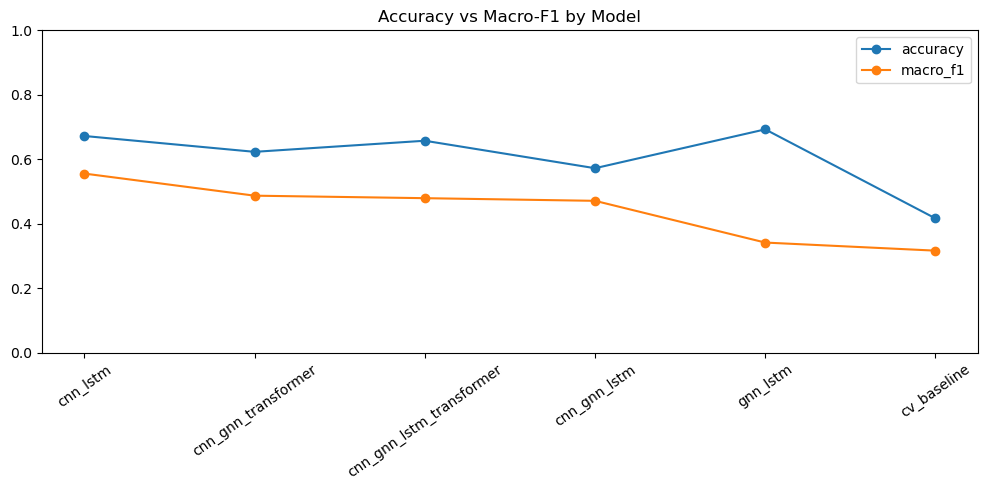

Saved: /home/basudeo/Documents/Thesis/Thesis_Repo/plots/comparison_accuracy_macro_f1.png


In [6]:
# Compare macro-F1 and accuracy together as a line plot.
ordered = summary_df.sort_values('macro_f1', ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ordered['model'], ordered['accuracy'], marker='o', label='accuracy')
ax.plot(ordered['model'], ordered['macro_f1'], marker='o', label='macro_f1')
ax.set_ylim(0.0, 1.0)
ax.set_title('Accuracy vs Macro-F1 by Model')
ax.legend()
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
out_path = THESIS_ROOT / 'plots' / 'comparison_accuracy_macro_f1.png'
plt.savefig(out_path, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', out_path)


,model,ADE,FDE,RMSE
0,cv_baseline,1.561741,2.601725,2.182193
1,cnn_lstm,0.308507,0.511918,0.419387
2,gnn_lstm,NaN,NaN,NaN
3,cnn_gnn_lstm,0.300089,0.490397,0.408637
4,cnn_gnn_transformer,0.288399,0.476695,0.399177
5,cnn_gnn_lstm_transformer,0.304640,0.506012,0.418296


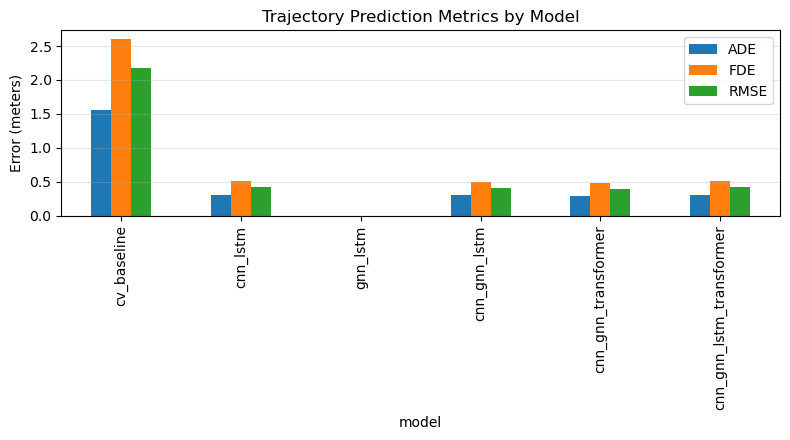

Saved trajectory comparison plot to /home/basudeo/Documents/Thesis/Thesis_Repo/plots/trajectory_metric_comparison.png


In [7]:
# Compare ADE / FDE / RMSE across models when trajectory-aware notebooks save them.
trajectory_metrics = ['ADE', 'FDE', 'RMSE']
trajectory_df = summary_df[['model']].copy()
for key in trajectory_metrics:
    trajectory_df[key] = summary_df[key] if key in summary_df.columns else np.nan

display(trajectory_df)

if not trajectory_df[trajectory_metrics].isna().all().all():
    plot_df = trajectory_df.set_index('model')
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_df.plot(kind='bar', ax=ax)
    ax.set_ylabel('Error (meters)')
    ax.set_title('Trajectory Prediction Metrics by Model')
    ax.grid(True, axis='y', alpha=0.3)
    fig.tight_layout()
    out_path = PLOTS_ROOT / 'trajectory_metric_comparison.png'
    fig.savefig(out_path, dpi=180)
    plt.show()
    print('Saved trajectory comparison plot to', out_path)
else:
    print('No ADE/FDE/RMSE values found yet in the latest metric files.')


In [8]:
# Pull the latest confusion matrices when available.
for slug in MODEL_SLUGS:
    latest_confusions = sorted((RESULTS_ROOT / slug).glob('confusion_*.csv'))
    if not latest_confusions:
        continue
    print('Latest confusion matrix for', slug)
    display(pd.read_csv(latest_confusions[-1], index_col=0))


Latest confusion matrix for cv_baseline


,go_to_goal,avoid_left,avoid_right,commit_forward,arrived
go_to_goal,182,23,40,16,0
avoid_left,0,30,0,1,0
avoid_right,0,1,29,0,0
commit_forward,80,45,39,13,0
arrived,111,0,0,0,0


Latest confusion matrix for cnn_lstm


,go_to_goal,avoid_left,avoid_right,commit_forward,arrived
go_to_goal,209,8,0,15,29
avoid_left,7,13,4,5,2
avoid_right,5,8,9,5,3
commit_forward,56,5,15,79,22
arrived,0,0,0,11,100


Latest confusion matrix for gnn_lstm


...

,go_to_goal,avoid_left,avoid_right,commit_forward,arrived
go_to_goal,141,6,6,83,25
avoid_left,4,3,13,9,2
avoid_right,1,2,14,9,4
commit_forward,50,17,14,80,16
arrived,0,0,0,0,111


Latest confusion matrix for cnn_gnn_transformer


,go_to_goal,avoid_left,avoid_right,commit_forward,arrived
go_to_goal,210,2,4,16,29
avoid_left,7,9,7,6,2
avoid_right,1,2,14,7,6
commit_forward,54,28,31,36,28
arrived,0,0,0,0,111


Latest confusion matrix for cnn_gnn_lstm_transformer


,go_to_goal,avoid_left,avoid_right,commit_forward,arrived
go_to_goal,202,0,12,16,31
avoid_left,7,0,16,4,4
avoid_right,1,0,17,9,3
commit_forward,54,1,36,71,15
arrived,0,0,0,0,111
